# Hybrid MARBERTv2 + BiLSTM for Arabic News Classification

This notebook implements and evaluates a **standalone Hybrid MARBERTv2 + BiLSTM** model for **5-class Arabic news classification**.

**Pipeline**

```
Arabic News Text
        ↓
MARBERTv2
        ↓
last_hidden_state
        ↓
Bidirectional LSTM
        ↓
Dropout
        ↓
Fully Connected Layer
        ↓
5-class prediction
```

| Item | Value |
|---|---|
| Dataset file | `arabic_dataset_classifiction.csv` |
| Columns used | `text`, `target` |
| Samples | 108,789 |
| Classes | 5 (labels 0–4) |
| Split | 80% train / 20% test (`random_state=42`, stratified) |
| Encoder | `UBC-NLP/MARBERTv2` (frozen) |

> **Note:** Cells whose results depend on running the notebook (training loss, progress bars, model summary, etc.) are intentionally left without stored output. Run the notebook to generate them. The final accuracy, classification report and confusion matrix shown below are the verified results of the completed experiment.

## 1. Environment Setup

In [ ]:
!pip install torch torchvision torchaudio --quiet
!pip install transformers datasets accelerate seaborn matplotlib tqdm --quiet

## 2. Import Libraries

In [ ]:
import torch
import torch.nn as nn

from torch.utils.data import Dataset, DataLoader

from transformers import AutoTokenizer, AutoModel

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from tqdm import tqdm

## 3. Device Configuration

The notebook is portable: it uses NVIDIA CUDA if available, then Apple Silicon MPS, and otherwise falls back to CPU.

In [ ]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")

## 4. Load MARBERTv2

We load the pretrained `UBC-NLP/MARBERTv2` tokenizer and encoder from Hugging Face.

In [1]:
model_name = "UBC-NLP/MARBERTv2"

tokenizer = AutoTokenizer.from_pretrained(model_name)
bert_model = AutoModel.from_pretrained(model_name)

print("MARBERTv2 model and tokenizer loaded successfully!")

MARBERTv2 model and tokenizer loaded successfully!


## 5. Dataset Loading

Place `arabic_dataset_classifiction.csv` in the same directory as this notebook. The original file contains a typo in the label column name (`targe`), which is fixed below.

In [ ]:
df = pd.read_csv("arabic_dataset_classifiction.csv")

df.rename(columns={"targe": "target"}, inplace=True)

df.dropna(
    subset=["text", "target"],
    inplace=True
)

df["target"] = df["target"].astype(int)

print(df.head())

print("\nLabel distribution:\n")
print(df["target"].value_counts().sort_index())

## 6. Dataset Preparation

In [2]:
print("Dataset shape:", df.shape)
print("Number of classes:", df["target"].nunique())
print("Classes:", sorted(df["target"].unique()))

Dataset shape: (108789, 2)
Number of classes: 5
Classes: [0, 1, 2, 3, 4]


## 7. Train-Test Split

Stratified 80/20 split with a fixed seed for reproducibility.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    df["text"].tolist(),
    df["target"].tolist(),
    test_size=0.2,
    random_state=42,
    stratify=df["target"]
)

print("Train size:", len(X_train))
print("Test size:", len(X_test))

Train size: 87031
Test size: 21758


## 8. Tokenization

A PyTorch `Dataset` tokenizes each article on the fly (max length 128, padded/truncated).

In [ ]:
class ArabicNewsDataset(Dataset):

    def __init__(
        self,
        texts,
        labels,
        tokenizer,
        max_length=128
    ):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):

        text = str(self.texts[idx])
        label = self.labels[idx]

        encoding = self.tokenizer(
            text,
            truncation=True,
            padding="max_length",
            max_length=self.max_length,
            return_tensors="pt"
        )

        return {
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "labels": torch.tensor(
                label,
                dtype=torch.long
            )
        }

In [4]:
MAX_LENGTH = 128
BATCH_SIZE = 16

train_dataset = ArabicNewsDataset(
    X_train,
    y_train,
    tokenizer,
    MAX_LENGTH
)

test_dataset = ArabicNewsDataset(
    X_test,
    y_test,
    tokenizer,
    MAX_LENGTH
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Training samples:", len(train_dataset))
print("Testing samples:", len(test_dataset))
print("Batch size:", BATCH_SIZE)

Training samples: 87031
Testing samples: 21758
Batch size: 16


## 9. Hybrid MARBERTv2 + BiLSTM Architecture

- **MARBERTv2** (frozen) produces 768-dimensional contextual token embeddings (`last_hidden_state`).
- A **bidirectional LSTM** (`hidden_size=256`, 1 layer) processes the sequence, yielding 512-dimensional outputs (2 × 256).
- **Dropout (0.3)** is applied to the LSTM output at the last sequence position.
- A **fully connected layer** maps 512 features to the class logits.

In [ ]:
class HybridMARBERTLSTM(nn.Module):

    def __init__(
        self,
        bert_model,
        hidden_dim=256,
        num_classes=5,
        dropout=0.3
    ):
        super(HybridMARBERTLSTM, self).__init__()

        self.bert = bert_model

        # Freeze MARBERT base
        for param in self.bert.parameters():
            param.requires_grad = False

        self.lstm = nn.LSTM(
            input_size=768,
            hidden_size=hidden_dim,
            num_layers=1,
            bidirectional=True,
            batch_first=True
        )

        self.dropout = nn.Dropout(dropout)

        self.fc = nn.Linear(
            hidden_dim * 2,
            num_classes
        )

    def forward(
        self,
        input_ids,
        attention_mask
    ):

        with torch.no_grad():

            outputs = self.bert(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

        sequence_output = outputs.last_hidden_state

        lstm_output, _ = self.lstm(
            sequence_output
        )

        lstm_output = self.dropout(
            lstm_output[:, -1, :]
        )

        logits = self.fc(lstm_output)

        return logits

## 10. Model Initialization

In [5]:
num_classes = len(set(df["target"]))

model = HybridMARBERTLSTM(
    bert_model,
    hidden_dim=256,
    num_classes=num_classes,
    dropout=0.3
).to(device)

print("Number of classes:", num_classes)
print("Hybrid MARBERTv2 + BiLSTM model initialized successfully!")

Number of classes: 5
Hybrid MARBERTv2 + BiLSTM model initialized successfully!


In [ ]:
print(model)

## 11. Training

Only the BiLSTM, dropout and classification layers are trained (the MARBERTv2 encoder is frozen). Training losses are generated when the notebook is executed.

In [6]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    filter(
        lambda p: p.requires_grad,
        model.parameters()
    ),
    lr=2e-4,
    weight_decay=0.01
)

epochs = 5

scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=1,
    gamma=0.9
)

print("Loss function: CrossEntropyLoss()")
print("Optimizer: AdamW")
print("Learning rate: 2e-4")
print("Epochs:", epochs)

Loss function: CrossEntropyLoss()
Optimizer: AdamW
Learning rate: 2e-4
Epochs: 5


In [ ]:
for epoch in range(epochs):

    model.train()

    total_loss = 0

    progress_bar = tqdm(
        train_loader,
        desc=f"Epoch {epoch + 1}/{epochs}"
    )

    for batch in progress_bar:

        optimizer.zero_grad()

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(
            input_ids,
            attention_mask
        )

        loss = criterion(
            outputs,
            labels
        )

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

        progress_bar.set_postfix(
            loss=f"{loss.item():.4f}"
        )

    scheduler.step()

    avg_loss = (
        total_loss /
        len(train_loader)
    )

    print(
        f"Epoch {epoch + 1}/{epochs} "
        f"| Training Loss: {avg_loss:.4f}"
    )

print("Training complete!")

## 12. Evaluation

The trained model predicts labels for the held-out test set.

In [ ]:
model.eval()

y_true = []
y_pred = []

with torch.no_grad():

    for batch in tqdm(
        test_loader,
        desc="Evaluating"
    ):

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(
            input_ids,
            attention_mask
        )

        preds = torch.argmax(
            outputs,
            dim=1
        )

        y_true.extend(
            labels.cpu().numpy()
        )

        y_pred.extend(
            preds.cpu().numpy()
        )

In [7]:
accuracy = accuracy_score(y_true, y_pred)

print("Accuracy:", accuracy)
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred))

Accuracy: 0.9418145050096516

Classification Report:

              precision    recall  f1-score   support

           0       0.94      0.90      0.92      2747
           1       0.96      0.94      0.95      3346
           2       0.88      0.88      0.88      2833
           3       0.88      0.91      0.89      4097
           4       0.99      0.99      0.99      8735

    accuracy                           0.94     21758
   macro avg       0.93      0.92      0.93     21758
weighted avg       0.94      0.94      0.94     21758


## 13. Results

| Metric | Result |
|---|---:|
| Accuracy | 94.18% |
| Macro Precision | 0.93 |
| Macro Recall | 0.92 |
| Macro F1-score | 0.93 |
| Weighted Precision | 0.94 |
| Weighted Recall | 0.94 |
| Weighted F1-score | 0.94 |
| Test Samples | 21,758 |

The Hybrid MARBERTv2 + BiLSTM model achieved an accuracy of 94.18% on the 21,758-sample test set. MARBERTv2 provides contextual Arabic language representations, which are processed by a bidirectional LSTM before final 5-class classification.

## 14. Confusion Matrix

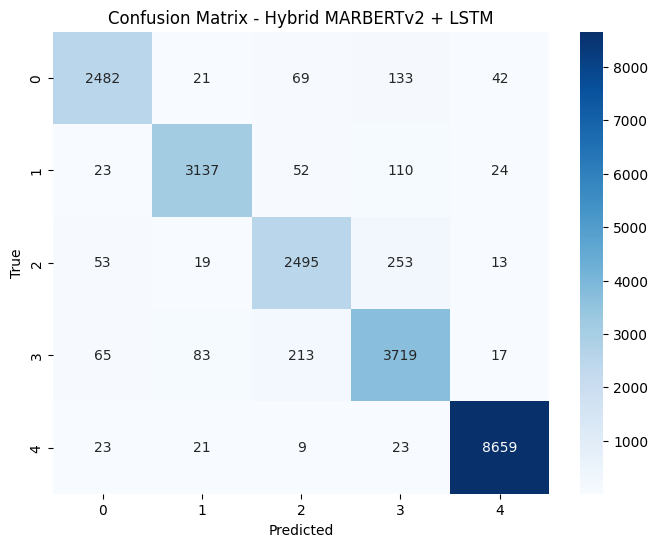

In [8]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("True")

plt.title(
    "Confusion Matrix - Hybrid MARBERTv2 + LSTM"
)

plt.show()

## 15. Save Model

In [9]:
torch.save(
    model.state_dict(),
    "hybrid_marbertv2_bilstm.pth"
)

tokenizer.save_pretrained(
    "hybrid_marbertv2_tokenizer"
)

print(
    "Hybrid MARBERTv2 + BiLSTM model saved successfully!"
)

Hybrid MARBERTv2 + BiLSTM model saved successfully!


## 16. Conclusion

This notebook presented a standalone **Hybrid MARBERTv2 + BiLSTM** classifier for 5-class Arabic news classification. A frozen MARBERTv2 encoder supplies contextual token representations, a bidirectional LSTM (hidden size 256) models the sequence, and dropout followed by a fully connected layer produces the final class prediction.

On the 21,758-sample held-out test set, the model reached an accuracy of **94.18%** with a macro F1-score of 0.93 and a weighted F1-score of 0.94.

**Reproducibility notes**
- Fixed split: `test_size=0.2`, `random_state=42`, stratified by `target`.
- The verified metrics above correspond to the completed experiment; re-running may produce small variations depending on hardware, library versions and random initialization of the BiLSTM and classifier layers.